<a href="https://colab.research.google.com/github/MaskeyRiddhi/AI-ML/blob/main/Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implement an End to End CNN Model for Image Classification Task.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

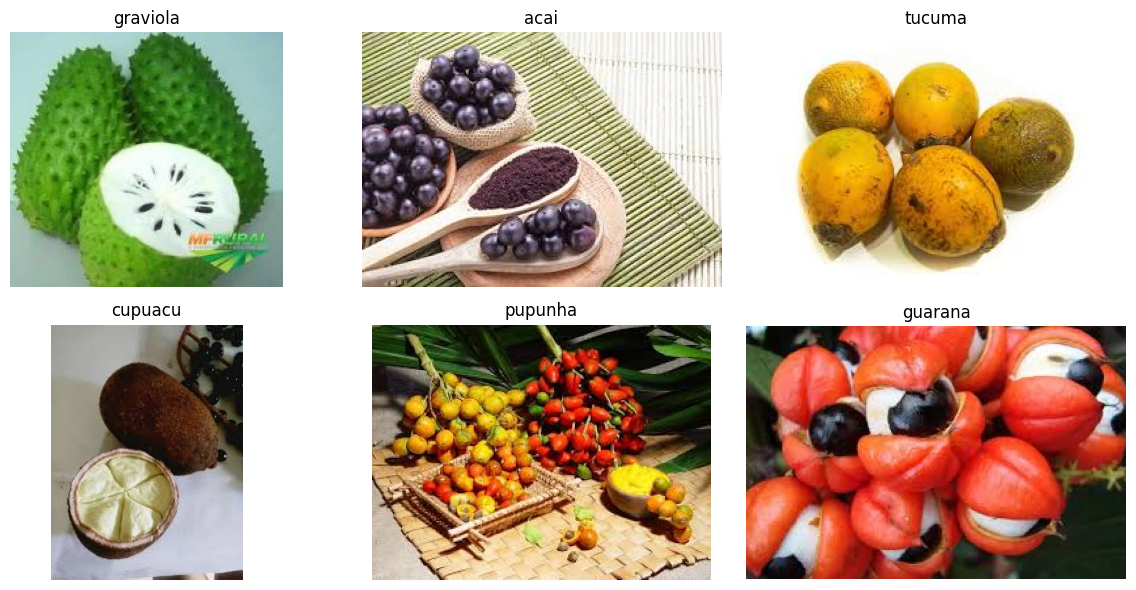

In [54]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Define the path to the training dataset
train_dir = '/content/drive/MyDrive/Artificial Intelligence/Week5/FruitinAmazon/train'  # Replace with the actual path if different

# Get the list of class directories
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Select one random image from each class
selected_images = []
class_labels = []

for class_dir in class_dirs:
    class_path = os.path.join(train_dir, class_dir)
    images = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

    if images:
        random_image = random.choice(images)
        selected_images.append(os.path.join(class_path, random_image))
        class_labels.append(class_dir)

# Determine grid size (2 rows)
num_classes = len(selected_images)
cols = (num_classes + 1) // 2  # Ensure two rows
rows = 2

# Create figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for idx, (image_path, label) in enumerate(zip(selected_images, class_labels)):
    img = Image.open(image_path)
    ax = axes[idx // cols, idx % cols]
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

# Remove empty subplots if any
for idx in range(len(selected_images), rows * cols):
    fig.delaxes(axes[idx // cols, idx % cols])

plt.tight_layout()
plt.show()


In [55]:
print(num_classes)

6


In [27]:
import os
from PIL import Image

# Define the path to the training dataset
train_dir = '/content/drive/MyDrive/Artificial Intelligence/Week5/FruitinAmazon/train'  # Replace with the actual path if different

# List all class directories
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

corrupted_images = []  # List to store corrupted image paths

# Iterate through each class subdirectory
for class_dir in class_dirs:
    class_path = os.path.join(train_dir, class_dir)

    # List all image files in the directory
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for image in images:
        image_path = os.path.join(class_path, image)

        try:
            # Attempt to open and verify the image
            with Image.open(image_path) as img:
                img.verify()  # Verify the image integrity

        except (IOError, SyntaxError):
            # If an error occurs, consider it a corrupted image
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final report
if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [28]:
# Dictionary to store class counts
class_counts = {}
for class_dir in class_dirs:
  class_path = os.path.join(train_dir, class_dir)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
  class_counts[class_dir] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
graviola                              15
acai                                  15
tucuma                                15
cupuacu                               15
pupunha                               15
guarana                               15


# Task 2: Loading and Preprocessing Image Data in keras:

In [29]:
import tensorflow as tf
from tensorflow.keras import layers
import os

# Set image dimensions and batch size
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2
seed = 123

In [30]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)


train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [31]:
# Path to the test folder
test_dir = '/content/drive/MyDrive/Artificial Intelligence/Week5/FruitinAmazon/test'  # Replace with the actual path if different

# Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int",  # or "categorical" if you trained that way
    shuffle=False  # Important for consistent evaluation
)

# Prefetch test dataset for performance
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


Found 30 files belonging to 6 classes.


In [32]:
# Data augmentation block
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Rescale input images to [0, 1]
rescale = layers.Rescaling(1./255)


In [33]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [34]:
from tensorflow.keras import models

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    rescale,

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])


In [35]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       8,388,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,409,798 (32.08 MB)

 Trainable params: 8,409,350 (32.08 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2513 - loss: 2.1425 - val_accuracy: 0.2778 - val_loss: 3.4949
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5699 - loss: 1.3552 - val_accuracy: 0.2778 - val_loss: 2.0826
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6523 - loss: 1.1235 - val_accuracy: 0.5556 - val_loss: 1.5721
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5334 - loss: 1.0262 - val_accuracy: 0.2222 - val_loss: 1.6696
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6593 - loss: 0.9624 - val_accuracy: 0.2222 - val_loss: 1.8916
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6016 - loss: 1.0015 - val_accuracy: 0.2222 - val_loss: 2.0521
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6623 - loss: 0.7715 - val_accuracy: 0.1111 - val_loss: 2.2334
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7609 - loss: 0.6817 - val_accuracy: 0.1111 - val_loss: 2.4137
Epoch 9/25
3/3 

In [36]:
from collections import Counter
val_labels = []

for _, labels in val_ds.unbatch():
    val_labels.append(int(labels.numpy()))

print("Validation class distribution:", Counter(val_labels))


Validation class distribution: Counter({3: 5, 4: 4, 5: 3, 2: 3, 1: 2, 0: 1})


# Image classification using fine tuning with VGG16

In [61]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [62]:
# Freeze the layers of the base model
for layer in base_model.layers:
  layer.trainable = False

In [64]:
# Add your custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
output_layer = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=output_layer)


In [66]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',  # use sparse if labels are integers
              metrics=['accuracy'])

model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1024)                │         525,3

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [67]:
img_height, img_width = 224, 224

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=32,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=32,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [68]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 19s/step - accuracy: 0.2227 - loss: 4.7383 - val_accuracy: 0.3333 - val_loss: 5.7221
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 88s 22s/step - accuracy: 0.6584 - loss: 1.8430 - val_accuracy: 0.6667 - val_loss: 1.9141
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 23s/step - accuracy: 0.8906 - loss: 0.4846 - val_accuracy: 0.6111 - val_loss: 1.8566
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 17s/step - accuracy: 0.9379 - loss: 0.2429 - val_accuracy: 0.6667 - val_loss: 2.7199
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 92s 22s/step - accuracy: 0.9813 - loss: 0.0768 - val_accuracy: 0.6667 - val_loss: 3.7398
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 22s/step - accuracy: 0.9783 - loss: 0.0437 - val_accuracy: 0.6667 - val_loss: 4.1377
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 22s/step - accuracy: 0.9891 - loss: 0.0173 - val_accuracy: 0.6667 - val_loss: 3.9945
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 23s/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.6667 - val_loss: 3.7760


In [69]:
import numpy as np
from sklearn.metrics import classification_report

# Predict on validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Generate report
print(classification_report(y_true, y_pred, target_names=class_dirs))


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         1
     cupuacu       0.25      0.50      0.33         2
    graviola       0.67      0.67      0.67         3
     guarana       1.00      0.60      0.75         5
     pupunha       0.40      0.50      0.44         4
      tucuma       1.00      0.67      0.80         3

    accuracy                           0.61        18
   macro avg       0.72      0.66      0.67        18
weighted avg       0.73      0.61      0.64        18

